**Сценарій 2**

Команда припускає, що поточна ціна підписки є нижчою за оптимальну. Планується перевірити вплив підвищення ціни на конверсію та виручку.

**Базові показники сценарію:**

**Кількість користувачів** - 89331

**Кількість покупок** - 4710

* **Baseline CR (конверсія в підписку):** 5.27%

* **Середній щоденний трафік:** 3000 користувачів

**Primary metric** - Conversion Rate to Subscription (CR) — частка користувачів, які оформили підписку після перегляду пропозиції.

**Secondary metric** - ARPU, Total revenue, ARPPU

**Guardrail metrics:**
Відсоток відмов від покупки
Частка користувачів, що дійшли до екрану оплати
SRM (перевірка коректності розподілу трафіку між групами)

**Гіпотези**

**Для конверсії:**

**H₀:** Конверсія в підписку однакова в групах A і B.

**H₁:** Конверсія в підписку відрізняється між групами A і B.

**Для доходу:**

**H₀:** Середній дохід на користувача (ARPU) однаковий у групах A і B.

**H₁:** Середній дохід на користувача (ARPU) відрізняється між групами A і B.

**Статистичні тести**

**Conversion Rate** → two-proportion z-test
Бо конверсія — це частка: купив / не купив.

**ARPU / Revenue per User → Welch’s t-test**
Оскільки нас цікавить саме середній дохід на користувача, а не просто форма розподілу.


Визначаємо розмір груп і тривалість тесту

In [108]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math

baseline = 0.0527
mde = 0.07                                                                 # відносний MDE 7%

p1 = baseline
p2 = baseline * (1 + mde)

effect_size = abs(proportion_effectsize(p1, p2))                          #розмір ефекту для порівняння двох ппропорцій, яка використовується у power функціях

analysis = NormalIndPower()

n_per_group = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1,                                                             #групи мають пропорцію 1:1
    alternative='two-sided')                                              # двосторонній тест)

group_size = math.ceil(float(n_per_group))
total_size = group_size*2
Duration = total_size / 3000
group_size, total_size, Duration
alpha = 0.05
beta = 0.8
print('group_size=', group_size, 'total_size =', total_size, 'Duration =', Duration)

group_size= 59470 total_size = 118940 Duration = 39.64666666666667


Для двостороннього тесту необхідний розмір вибірки склав 59 470 користувачів на групу або 118 940 користувачів загалом.

За середнього денного трафіку 3 000 користувачів очікувана тривалість експерименту становила близько 40 днів.

Завантажуємо результат

In [109]:
import pandas as pd
df = pd.read_csv('stepup_ab_dataset_scenario_2.csv')
df.head()

,user_id,group,converted,revenue,session_duration_sec,pages_viewed,clicks,device_type,traffic_source,date
0,usr_a_10000,A,0,0.0,83,2,9,Mobile,Email,2026-05-01
1,usr_a_10001,A,0,0.0,74,1,10,Mobile,Organic,2026-05-01
2,usr_a_10002,A,0,0.0,74,1,5,Desktop,Organic,2026-05-01
3,usr_a_10003,A,0,0.0,89,3,7,Desktop,Email,2026-05-01
4,usr_a_10004,A,0,0.0,88,2,11,Mobile,Organic,2026-05-01


In [110]:
df.shape

(118940, 10)

Фінальний датасет містить 118 940 користувачів та охоплює 40 календарних днів.

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118940 entries, 0 to 118939
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   user_id               118940 non-null  object 
 1   group                 118940 non-null  object 
 2   converted             118940 non-null  int64  
 3   revenue               118940 non-null  float64
 4   session_duration_sec  118940 non-null  int64  
 5   pages_viewed          118940 non-null  int64  
 6   clicks                118940 non-null  int64  
 7   device_type           118940 non-null  object 
 8   traffic_source        118940 non-null  object 
 9   date                  118940 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 9.1+ MB


Перевіряємо тривалість тесту у датасеті

In [112]:
df['date'] = pd.to_datetime(df['date'])

In [113]:
df['date'].max() - df['date'].min()

Timedelta('39 days 00:00:00')

In [114]:
df['date'].nunique()

40

Оцінюємо конверсії по групах

In [115]:
group_stat = df.groupby('group')['converted'].agg(
    users = 'count',
     conversions='sum',
    conversion_rate='mean'
)
group_stat

,users,conversions,conversion_rate
group,,,
A,59470,3137,0.052749
B,59470,3182,0.053506


Оцінюємо дохід по групах

In [117]:
revenue_stat = df.groupby('group')['revenue'].agg(
    users = 'count',
    total_revenue='sum',
    ARPU='mean'
)
revenue_stat

,users,total_revenue,ARPU
group,,,
A,59470,15653.63,0.263219
B,59470,18614.70,0.313010


Перевіряємо чи немає ситуацій, коли дохід відобразився без покупки

In [118]:
((df['converted'] == 0) & (df['revenue'] > 0)).sum()

np.int64(0)

Перевіряємо чи є ситуації, коли покупка є, але без доходу

In [119]:
((df['converted'] == 1) & (df['revenue'] == 0)).sum()

np.int64(0)

Перевіряємо наявність пустих рядків

In [120]:
df.isna().sum()

,0
user_id,0
group,0
converted,0
revenue,0
session_duration_sec,0
pages_viewed,0
clicks,0
device_type,0
traffic_source,0
date,0


Перевіряємо, чи немає перекосу по типах пристроїв

In [121]:
pd.crosstab(df['group'], df['device_type'])

device_type,Desktop,Mobile
group,,
A,26890,32580
B,26840,32630


Перевіряємо чи немає перекосу по джерелах трафіку у групах

In [123]:
pd.crosstab(df['group'], df['traffic_source'])

traffic_source,Email,Organic,Paid
group,,,
A,11294,27242,20934
B,11258,27111,21101


In [124]:
uplift_conv = (                                           #фактичний відносний приріст конверсії між групами
    df[df.group=='B']['converted'].mean()
    /
    df[df.group=='A']['converted'].mean()
    - 1
)

print(f"{uplift_conv:.2%}")

1.43%


In [125]:
uplift_rev= (                                           #фактичний відносний приріст доходу між групами
    df[df.group=='B']['revenue'].mean()
    /
    df[df.group=='A']['revenue'].mean()
    - 1
)

print(f"{uplift_rev:.2%}")

18.92%


Оцінюємо скільки людей заплатило за старою і за новою ціною

In [126]:
df[df['converted']==1].groupby('group')['revenue'].value_counts()

,,count
group,revenue,
A,4.99,3137
B,5.85,3182


Проводимо z-test для оцінки зміни конверсії

In [127]:
from statsmodels.stats.proportion import proportions_ztest
success_A = group_stat.loc['A', 'conversions']        #кількість конверсій
success_B = group_stat.loc['B', 'conversions']

n_A = group_stat.loc['A', 'users']            #загальна кількість користувачів у групі
n_B = group_stat.loc['B', 'users']

count = [success_B, success_A]
nobs = [n_B, n_A]

z_stat, cr_p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='two-sided'                       # односторонній тест: перевіряємо, чи B > A
)

print("z-statistic:", round(z_stat, 4))
print("cr_p_value:", round(cr_p_value, 8))
if cr_p_value < 0.05:
    print("Статистично значущий результат")
else:
    print("Недостатньо доказів")

z-statistic: 0.5818
cr_p_value: 0.56072947
Недостатньо доказів


Не виявлено статистично значущої різниці в конверсії між групами A та B.

Проводимо Welsh's t-test для оцінки зміни доходу

In [128]:
revenue_A = df[df['group'] == 'A']['revenue']
revenue_B = df[df['group'] == 'B']['revenue']

In [129]:
from scipy.stats import ttest_ind
t_stat, arpu_p_value = ttest_ind(
    revenue_B,
    revenue_A,
    equal_var=False,      #Якщо False, виконати t-тест Welch’s, який не припускає рівній дисперсії генеральної сукупності [2
    alternative='two-sided'
)

print("t-statistic =", round(t_stat, 4))
print("arpu_p_value =", round(arpu_p_value, 8))
if arpu_p_value < 0.05:
    print("Статистично значущий результат")
else:
    print("Недостатньо доказів")



t-statistic = 7.0369
arpu_p_value = 0.0
Статистично значущий результат


Відхиляємо H₀. Середній дохід на користувача (ARPU) у групі B статистично значуще зріс порівняно з групою A.

Створюємо таблицю з результатами тесту

In [130]:
results = pd.DataFrame({
    'Metric': ['Conversion Rate', 'ARPU', 'Total Revenue', 'ARPPU'],
    'Group A': [
        df[df.group=='A']['converted'].mean(),
        df[df.group=='A']['revenue'].mean(),
        df[df.group=='A']['revenue'].sum(),
        df[(df['converted']==1) & (df['group']=='A')]['revenue'].mean()

    ],
    'Group B': [
        df[df.group=='B']['converted'].mean(),
        df[df.group=='B']['revenue'].mean(),
        df[df.group=='B']['revenue'].sum(),
        df[(df['converted']==1) & (df['group']=='B')]['revenue'].mean()
    ],

    'Uplift': [
        df[df.group=='B']['converted'].mean()/df[df.group=='A']['converted'].mean() -1,
        df[df.group=='B']['revenue'].mean()/df[df.group=='A']['revenue'].mean() -1,
        df[df.group=='B']['revenue'].sum()/df[df.group=='A']['revenue'].sum() -1,
        df[(df['converted']==1) & (df['group']=='B')]['revenue'].mean()/df[(df['converted']==1) & (df['group']=='A')]['revenue'].mean() -1
    ]

})

results['Group A'] = results['Group A'].round(4)
results['Group B'] = results['Group B'].round(4)
results['Uplift'] = results['Uplift'] * 100
results['Uplift'] = results['Uplift'].round(2)


results

,Metric,Group A,Group B,Uplift
0,Conversion Rate,0.0527,0.0535,1.43
1,ARPU,0.2632,0.3130,18.92
2,Total Revenue,15653.6300,18614.7000,18.92
3,ARPPU,4.9900,5.8500,17.23


In [134]:
results_tests = pd.DataFrame({
    'Metric': ['Conversion Rate', 'ARPU'],
    'Test': ['Two-Proportion Z-Test', "Welch's T-Test"],
    'p-value': [cr_p_value, arpu_p_value],
    'Result': [
        'Not Significant' if cr_p_value >= 0.05 else 'Significant',
        'Not Significant' if arpu_p_value >= 0.05 else 'Significant'
    ]
})

results_tests

,Metric,Test,p-value,Result
0,Conversion Rate,Two-Proportion Z-Test,5.607295e-01,Not Significant
1,ARPU,Welch's T-Test,1.975896e-12,Significant


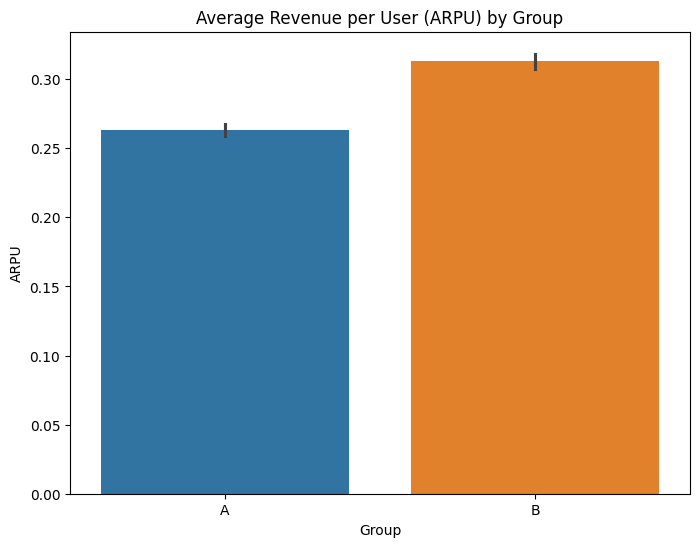

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(
    x='group',
    y='revenue',
    hue='group',
    data=df,
    errorbar=('se'),
    legend=False
)

plt.title('Average Revenue per User (ARPU) by Group')
plt.xlabel('Group')
plt.ylabel('ARPU')

plt.show()

**Висновок**

Підвищення ціни підписки не призвело до статистично значущої зміни конверсії (p-value = 0.56).

Водночас середній дохід на користувача (ARPU) зріс на 18.92%, а загальна виручка збільшилася на 18.92%.

Отримані результати свідчать, що нова ціна покращує монетизацію продукту без статистично значущого негативного впливу на конверсію.

Рекомендація: впровадити нову ціну підписки.
Для остаточного підтвердження результатів доцільно додатково контролювати поведінкові метрики та довгострокове утримання користувачів після впровадження змін.